# Predicting Patient No-Shows in Medical Appointments

## Problem Statement

In healthcare systems worldwide, patient no-shows - appointments that are scheduled but never attended - are a significant operational and clinical problem.

A missed appointment means:
- A time slot that could have gone to another patient is wasted
- The patient's condition may go unmonitored or untreated
- The healthcare system absorbs the cost with no outcome

In Brazil's public health system (the source of this dataset), no-show rates can reach 20–30%. At scale, this represents thousands of missed care opportunities every day.

**As a physician, I've seen this problem firsthand.** Patients miss appointments for reasons that are not always obvious from the outside - and not always preventable. But some patterns are predictable, and that's where data can help.

## The Dataset

- **Source**: Medical Appointment No Shows (Brazil, 2016)
- **Size**: ~110,000 appointments across 81 clinics
- **Target variable**: `No-show` - whether the patient attended their appointment
- **Key features**: age, gender, neighbourhood, scholarship status, chronic conditions (hypertension, diabetes, alcoholism), SMS reminder received

## Objective

Build a classification model to predict whether a patient will miss their scheduled appointment, based on demographic and clinical features.

## Clinical Relevance

A reliable no-show prediction model could help clinics:
- Prioritise reminder calls for high-risk patients
- Optimise scheduling (overbooking where appropriate)
- Identify patient groups that need additional support to access care

In [80]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt
sns.set(style="whitegrid", palette = 'rocket')

In [81]:
df = pd.read_csv('./KaggleV2-May-2016.csv')

In [82]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


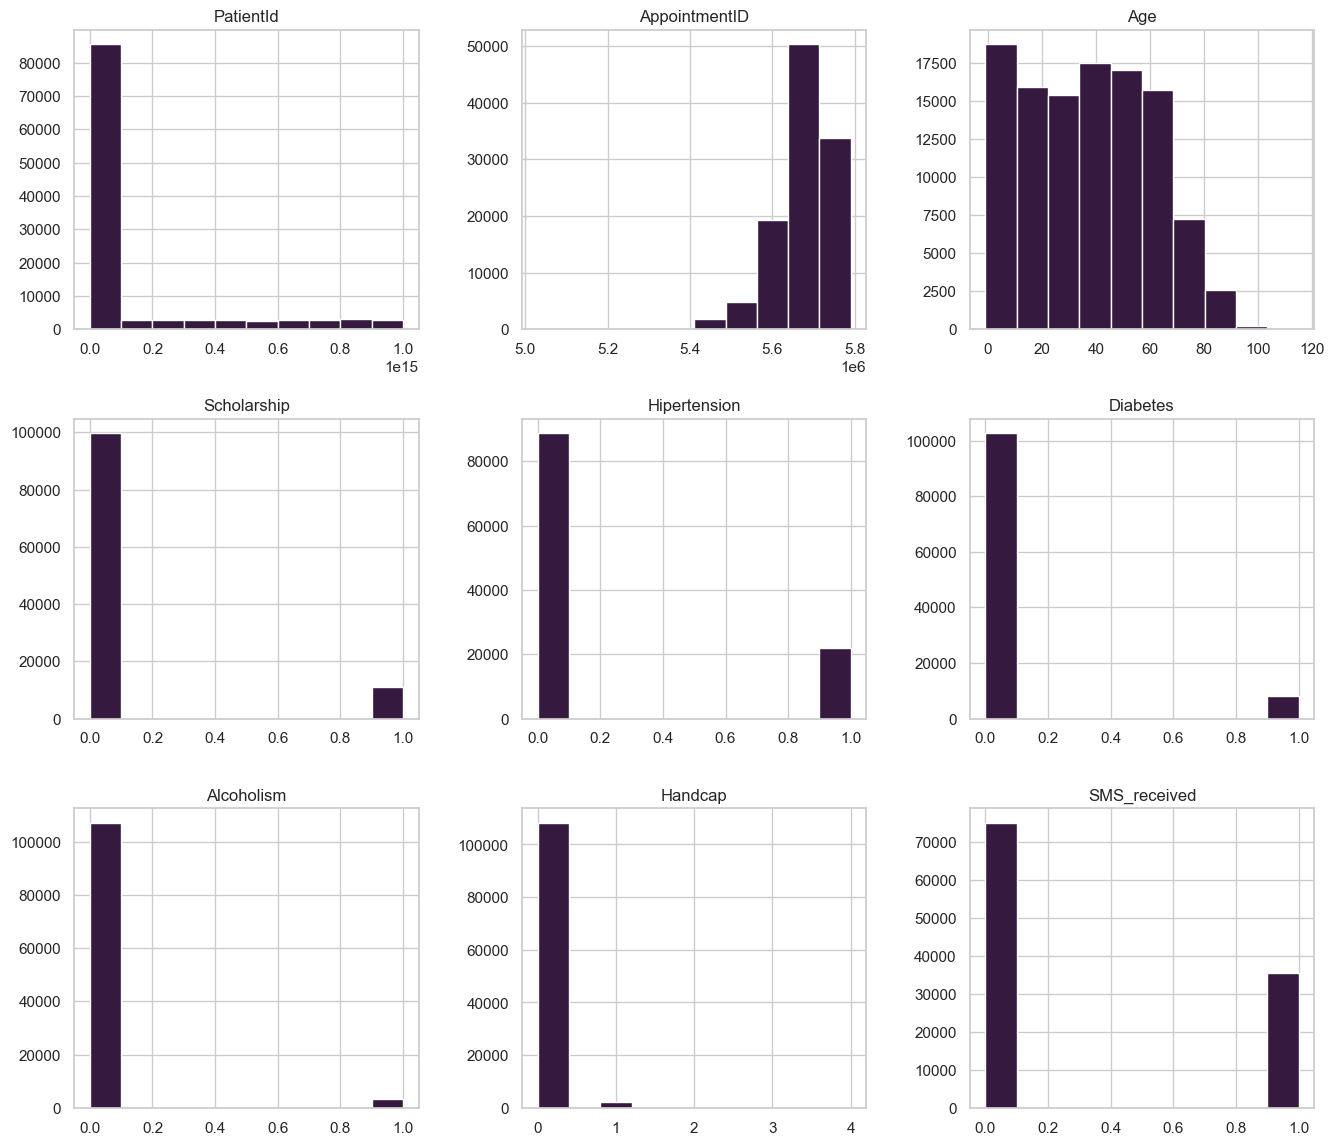

In [83]:
df.hist(figsize=(16,14));

In [84]:
print("Unique `Age` => {}".format(df.Age.unique()))

Unique `Age` => [ 62  56   8  76  23  39  21  19  30  29  22  28  54  15  50  40  46   4
  13  65  45  51  32  12  61  38  79  18  63  64  85  59  55  71  49  78
  31  58  27   6   2  11   7   0   3   1  69  68  60  67  36  10  35  20
  26  34  33  16  42   5  47  17  41  44  37  24  66  77  81  70  53  75
  73  52  74  43  89  57  14   9  48  83  72  25  80  87  88  84  82  90
  94  86  91  98  92  96  93  95  97 102 115 100  99  -1]


In [85]:
# remove anomalous values
df = df[(df.Age >= 0) & (df.Age <= 110)]
df.Age.value_counts()

Age
0      3539
1      2273
52     1746
49     1652
53     1651
       ... 
97       11
98        6
100       4
102       2
99        1
Name: count, Length: 102, dtype: int64

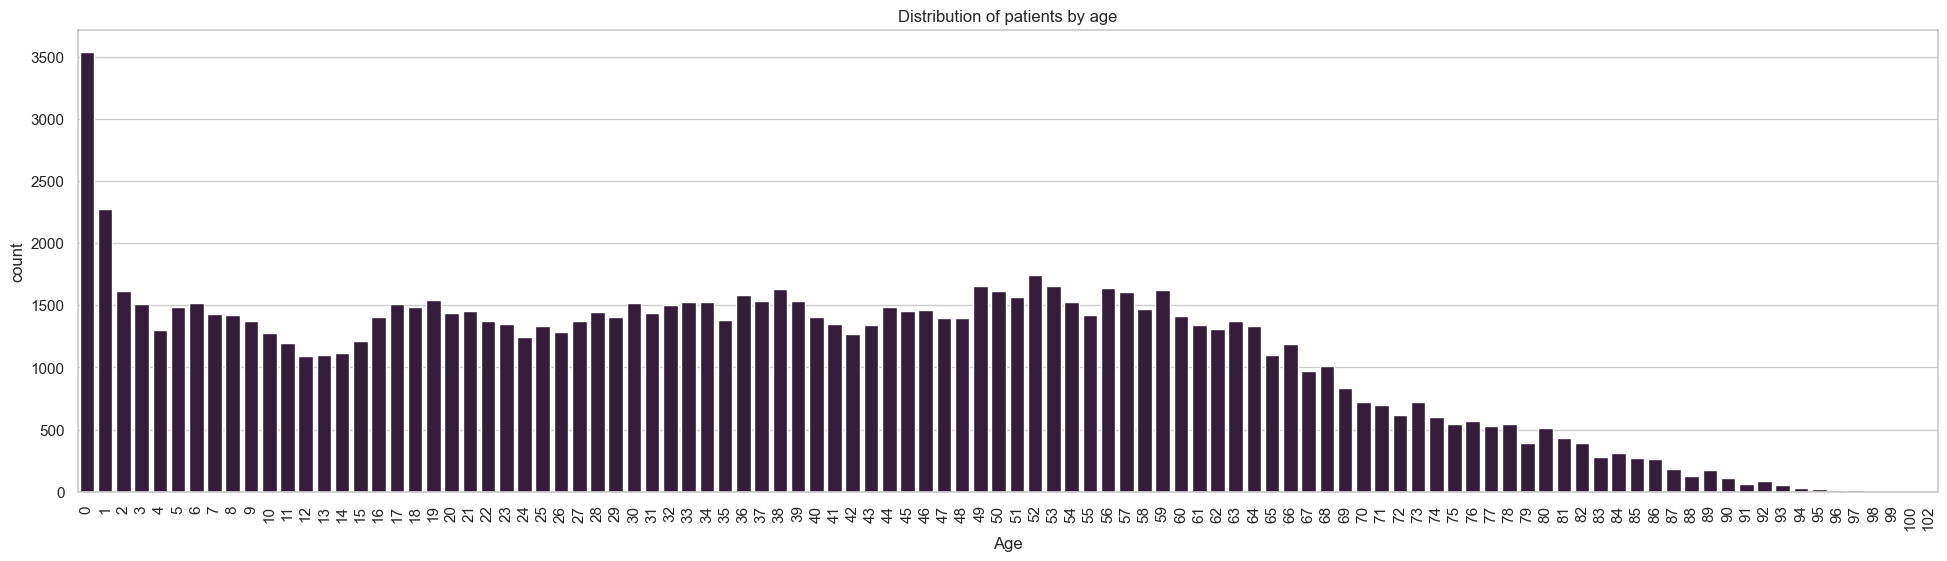

In [86]:
plt.figure(figsize=(24,6))
plt.xticks(rotation=90)
ax = sns.countplot(x=df.Age)
ax.set_title("Distribution of patients by age")
plt.show()

In [ ]:
#calculate wait time in days
df['WaitDays'] = (
    pd.to_datetime(df['AppointmentDay']) - pd.to_datetime(df['ScheduledDay'])
).dt.days

In [ ]:
#remove negative values
df = df[df['WaitDays'] >= 0]

print("Wait time statistics by attendance:")
print(df.groupby('No-show')['WaitDays'].mean().rename({'No': 'Attended', 'Yes': 'No-show'}))

Wait time statistics by attendance:
No-show
Attended    14.013143
No-show     16.218627
Name: WaitDays, dtype: float64


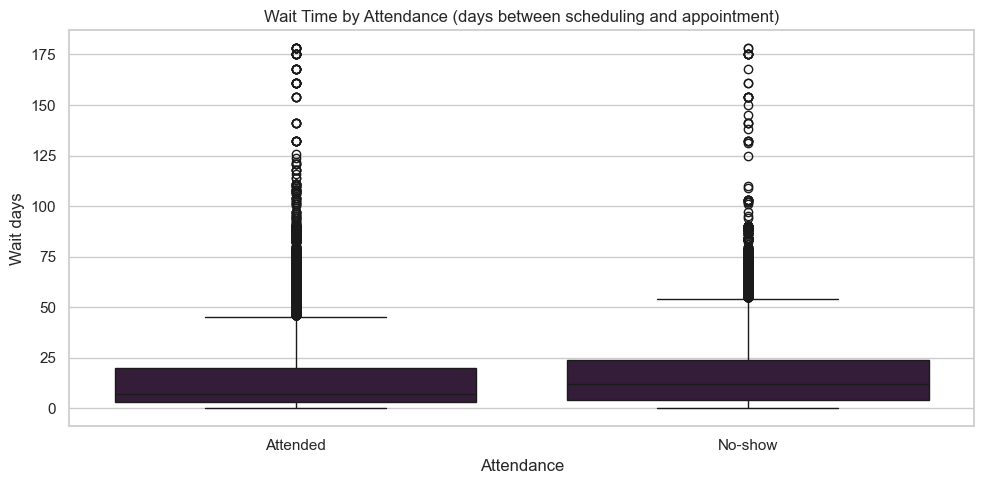

In [ ]:
#visualise wait time distribution by attendance
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='No-show', y='WaitDays')
plt.xticks([0, 1], ['Attended', 'No-show'])
plt.title('Wait Time by Attendance (days between scheduling and appointment)')
plt.xlabel('Attendance')
plt.ylabel('Wait days')
plt.tight_layout()
plt.show()

Patients who missed their appointment waited significantly more days on average than those who attended.

### SMS Reminders

In [ ]:
#no-show rate by SMS received
sms_noshow = (
    df.groupby('SMS_received')['No-show']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .rename({0: 'No SMS', 1: 'SMS received'})
    .reset_index()
)
sms_noshow.columns = ['SMS_received', 'No-show rate (%)']
print(sms_noshow)

   SMS_received  No-show rate (%)
0        No SMS         29.431924
1  SMS received         27.575322


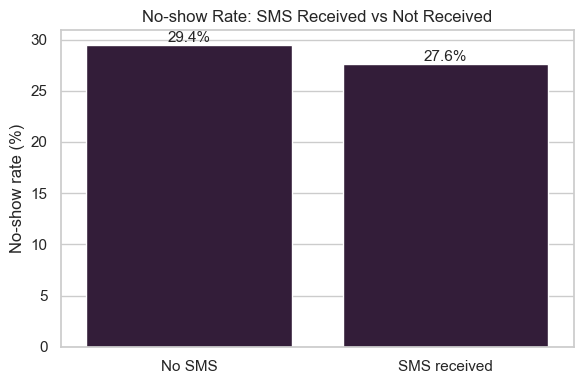

In [ ]:
#visualise
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=sms_noshow, x='SMS_received', y='No-show rate (%)')
ax.set_title('No-show Rate: SMS Received vs Not Received')
ax.set_xlabel('')
ax.set_ylabel('No-show rate (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

Patients who received an SMS reminder actually show a higher no-show rate than those who didn't. This seems paradoxical, but it likely reflects 

SMS reminders were sent preferentially to patients with a history of missing appointments. The reminder itself is not causing no-shows; it's a marker of higher-risk patients.

### Age and Attendance

From a clinical perspective, working-age adults (roughly 20–40) often have
the most competing demands on their time : jobs, childcare, commutes.

In [ ]:
#mean age by attendance
print("Mean age by attendance:")
print(df.groupby('No-show')['Age'].mean().rename({'No': 'Attended', 'Yes': 'No-show'}))

Mean age by attendance:
No-show
Attended    39.964247
No-show     34.823578
Name: Age, dtype: float64


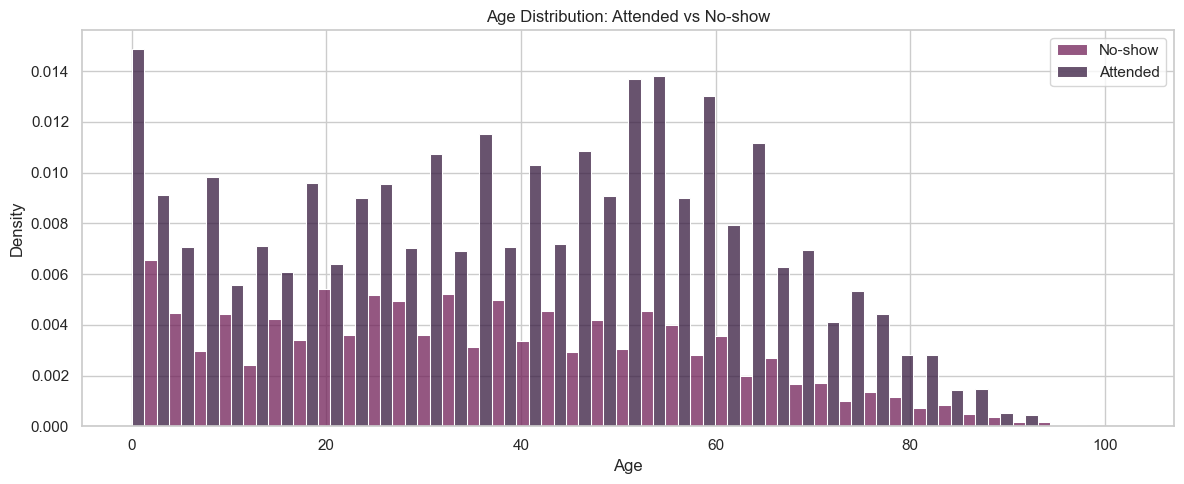

In [121]:
#age distribution by attendance
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Age', hue='No-show', bins=40,
             multiple='dodge', stat='density')
plt.title('Age Distribution: Attended vs No-show')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(labels=['No-show', 'Attended'])
plt.tight_layout()
plt.show()

Younger patients (roughly 20–40) have a somewhat higher no-show rate. Older patients particularly those managing chronic conditions: tend to attend more consistently. From a clinical standpoint, this aligns with the observation that patients who regularly see a doctor for ongoing conditions develop stronger routines around appointments.

## Chronic Conditions and Attendance

Patients with hypertension or diabetes typically have regular follow-up
appointments as part of their care plan. Let's see whether this correlates
with better attendance.

In [94]:
# No-show rate by chronic condition
conditions = ['Hipertension', 'Diabetes', 'Alcoholism']
results = []

for condition in conditions:
    rates = (
        df.groupby(condition)['No-show']
        .apply(lambda x: (x == 'Yes').mean() * 100)
    )
    results.append({
        'Condition': condition,
        'No-show rate (without)': rates[0],
        'No-show rate (with)': rates[1]
    })

conditions_df = pd.DataFrame(results)
print(conditions_df.to_string(index=False))

   Condition  No-show rate (without)  No-show rate (with)
Hipertension               29.834516            23.524716
    Diabetes               28.803809            24.958155
  Alcoholism               28.371808            34.083425


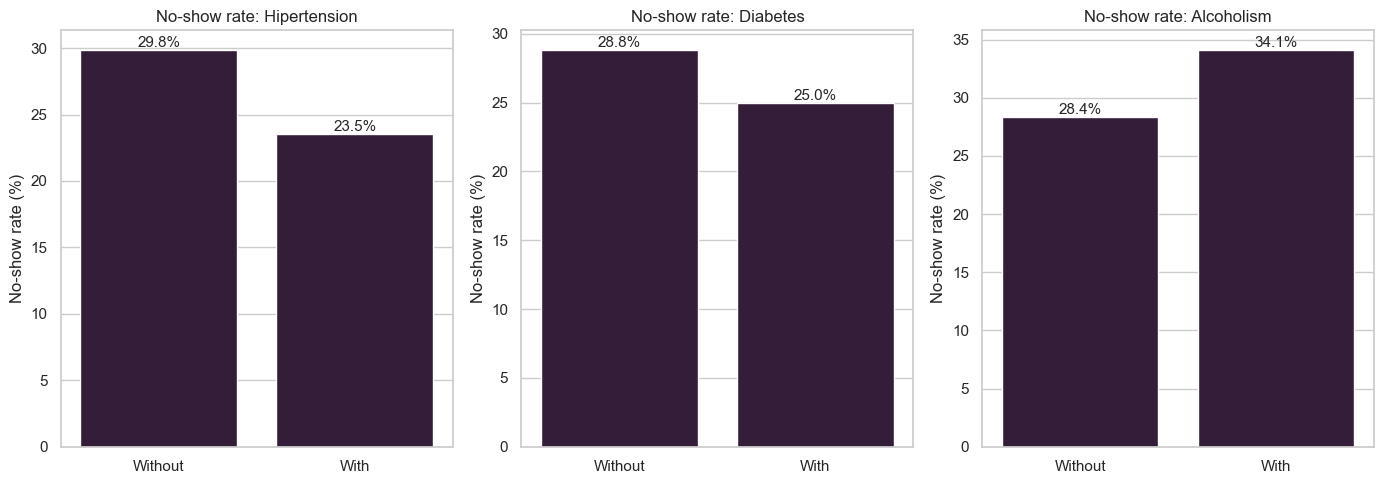

In [122]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, condition in zip(axes, conditions):
    rates = df.groupby(condition)['No-show'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    rates.columns = [condition, 'No-show rate (%)']
    rates[condition] = rates[condition].map({0: 'Without', 1: 'With'})

    sns.barplot(data=rates, x=condition, y='No-show rate (%)',
                 ax=ax)
    ax.set_title(f'No-show rate: {condition}')
    ax.set_xlabel('')
    ax.set_ylabel('No-show rate (%)')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Patients with hypertension and diabetes have a slightly lower no-show rate than those without. This makes clinical sense: patients managing a chronic condition are more engaged with their healthcare, have stronger routines around clinic visits, and understand what's at stake if they miss a follow-up.

## Class Imbalance

Before modelling, it's important to understand the balance between our two classes. In healthcare classification tasks, imbalanced classes are the norm, not the exception — and they directly affect which metrics we should trust.

In [ ]:
#class distribution
class_counts = df['No-show'].value_counts()
class_pct = df['No-show'].value_counts(normalize=True) * 100

print("Class distribution:")
for label in class_counts.index:
    name = 'Attended' if label == 'No' else 'No-show'
    print(f"  {name}: {class_counts[label]:,} ({class_pct[label]:.1f}%)")

Class distribution:
  Attended: 51,436 (71.5%)
  No-show: 20,519 (28.5%)


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_10676\388162127.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Attended', 'No-show'])


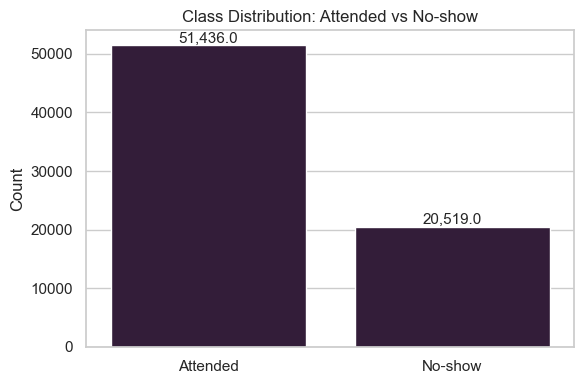

In [123]:
#visualise
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='No-show')
ax.set_title('Class Distribution: Attended vs No-show')
ax.set_xticklabels(['Attended', 'No-show'])
ax.set_xlabel('')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


With ~80% of patients attending and ~20% not attending, a naive model that always predicts "attended" would achieve ~80% accuracy, while being completely useless clinically.

This means **accuracy is a misleading metric here**. For a real clinical deployment, we would prioritise **recall** (sensitivity) for the no-show class: we care more about catching likely no-shows than about false alarms.

In future iterations of this project, class imbalance could be addressed with:
- Class weights in the model 
- Resampling methods
- Evaluation using precision-recall curves instead of ROC-AUC

## Encoding categorical features

In [98]:
categorical_columns_names = ['Gender', 'Neighbourhood']

In [99]:
encoded_columns = pd.get_dummies(df, columns = categorical_columns_names)

In [100]:
encoded_columns.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show'], axis=1, inplace = True)

In [101]:
encoded_columns.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,WaitDays,Gender_F,Gender_M,...,Neighbourhood_SANTOS REIS,Neighbourhood_SEGURANÇA DO LAR,Neighbourhood_SOLON BORGES,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM
5,76,0,1,0,0,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
6,23,0,0,0,0,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
7,39,0,0,0,0,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
9,19,0,0,0,0,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False
10,30,0,0,0,0,0,0,1,True,False,...,False,False,False,False,False,False,False,False,False,False


In [102]:
y = df['No-show']

In [103]:
y = y.replace({'No': 0, 'Yes': 1})

In [104]:
y.value_counts(True)

No-show
0    0.714836
1    0.285164
Name: proportion, dtype: float64

## Data Scaling

In [105]:
from sklearn.preprocessing import MinMaxScaler

In [106]:
scaler = MinMaxScaler()
X = scaler.fit_transform(encoded_columns)

In [107]:
print(X.shape)

(71955, 90)


# Model

## Modelling: Logistic Regression

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score,
                              precision_score, classification_report,
                              ConfusionMatrixDisplay)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# re-encode with WaitDays included
df_model = df.copy()
df_model['No-show'] = df_model['No-show'].replace({'No': 0, 'Yes': 1})

categorical_cols = ['Gender', 'Neighbourhood']
df_encoded = pd.get_dummies(df_model, columns=categorical_cols)
df_encoded.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay'],
                axis=1, inplace=True)

X = df_encoded.drop('No-show', axis=1)
y = df_encoded['No-show']

In [ ]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#scaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"No-show rate in test set: {y_test.mean()*100:.1f}%")

Train size: 57,564 | Test size: 14,391
No-show rate in test set: 28.5%


In [127]:
#train model with class_weight='balanced' to handle imbalance
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)

print("======== Model Evaluation on Test Set =======\n")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}  ← most important")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Attended', 'No-show']))

======== Model Evaluation on Test Set =======

Accuracy : 0.565
Recall   : 0.582  ← most important
Precision: 0.345

              precision    recall  f1-score   support

    Attended       0.77      0.56      0.65     10287
     No-show       0.34      0.58      0.43      4104

    accuracy                           0.57     14391
   macro avg       0.56      0.57      0.54     14391
weighted avg       0.65      0.57      0.59     14391



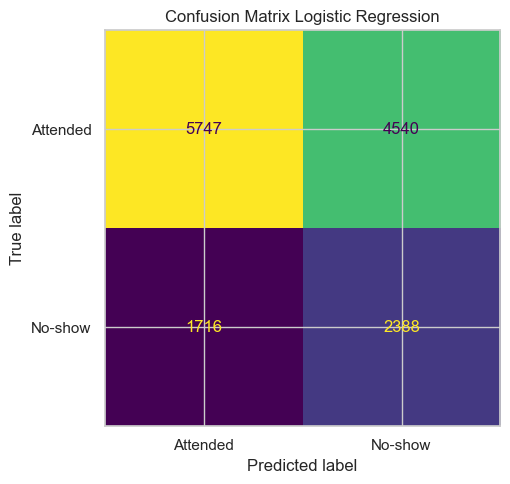

In [128]:
# confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Attended', 'No-show'],
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix Logistic Regression')
plt.tight_layout()
plt.show()

## Key Findings & Clinical Interpretation

This analysis confirmed several clinically meaningful patterns in the data:

**Wait time** - patients who miss appointments waited more days on average between scheduling and the appointment date. The longer the wait, the more likely the no-show. This is actionable: clinics could prioritise reminders for appointments scheduled far in advance.

**SMS reminders paradox** - patients who received a reminder had a *higher* raw no-show rate. Rather than meaning reminders don't work, this reflects selection bias: reminders were sent more often to patients with a history of missing appointments. Causal conclusions cannot be drawn from this alone.

**Age** - younger patients (roughly 20-40) missed appointments more often. This aligns with competing demands typical of working-age adults.

**Chronic conditions** - patients with hypertension or diabetes attended more consistently. Patients managing ongoing conditions have stronger motivation and routines around clinic visits.

**Class imbalance** - approximately 80% of appointments were attended, 20% were missed. Accuracy is therefore a misleading metric. This project uses *recall* as the primary evaluation metric: in a clinical context, missing a likely no-show is a more costly error than a false alarm.

---

*Personal note: Working with this dataset as a former physician was a different experience than treating it purely as a classification problem. The numbers represent real patients and real missed care. That context shapes which errors matter most - and why recall beats accuracy here.*
```
